In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/varshatiwari2410/mnist-dataset-cnn-implementation-from-scratch/train.csv
/kaggle/input/datasets/varshatiwari2410/mnist-dataset-cnn-implementation-from-scratch/test.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [23]:
train = pd.read_csv('/kaggle/input/datasets/varshatiwari2410/mnist-dataset-cnn-implementation-from-scratch/train.csv')
test = pd.read_csv('/kaggle/input/datasets/varshatiwari2410/mnist-dataset-cnn-implementation-from-scratch/test.csv')

print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


In [6]:
train.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
test.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [10]:
print(train.shape[1])

784


In [11]:
print(train.columns)

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784)


In [12]:
train.isnull().sum()

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 784, dtype: int64

In [13]:
test.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

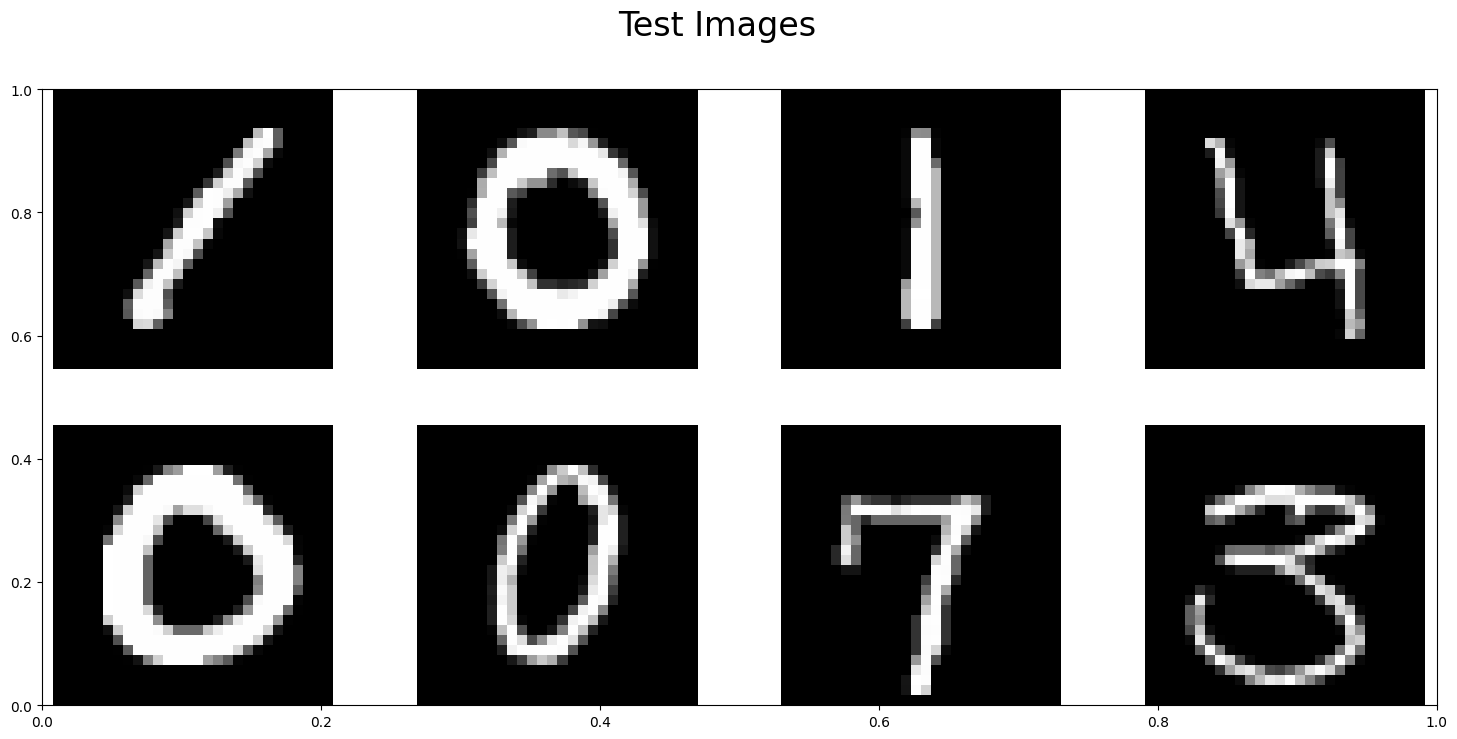

In [14]:
fig, ax = plt.subplots(figsize=(18,8))

for ind, row in test.iloc[:8,:].iterrows():

    plt.subplot(2,4,ind+1)

    img = row.iloc[1:].to_numpy().reshape(28,28)

    plt.imshow(img, cmap='gray')
    plt.axis('off')

fig.suptitle("Test Images", fontsize=24)

plt.show()

In [18]:
X = train.values
test = test.iloc[:, 1:].values

print(X.shape)
print(test.shape)

X = X.reshape(-1, 28, 28, 1)
test = test.reshape(-1, 28, 28, 1)

print(X.shape)
print(test.shape)

(28000, 784)
(42000, 784)
(28000, 28, 28, 1)
(42000, 28, 28, 1)


In [21]:
# Features and labels
X = train.iloc[:, 1:].to_numpy()
y = train['label'].to_numpy()

# Test data
test = test.to_numpy()

# Normalize
X = X / 255.0
test = test / 255.0

KeyError: 'label'

In [22]:
print(train.columns)
print(train.shape)
train.head()

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784)
(28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Features and labels
X = train.iloc[:, 1:].to_numpy()
y = train.iloc[:, 0].to_numpy()

# Test data
test = test.to_numpy()

print(X.shape)
print(y.shape)
print(test.shape)

(42000, 784)
(42000,)
(28000, 784)


In [25]:
# Normalize pixel values (0–255 → 0–1)

X = X / 255.0
test = test / 255.0

print(X.min(), X.max())
print(test.min(), test.max())

0.0 1.0
0.0 1.0


In [26]:
# Reshape for CNN

X = X.reshape(-1, 28, 28, 1)
test = test.reshape(-1, 28, 28, 1)

print(X.shape)
print(test.shape)

(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(33600, 28, 28, 1)
(8400, 28, 28, 1)
(33600,)
(8400,)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782969762.231933      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782969762.234624      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9973 - loss: 0.0078 - val_accuracy: 0.9850 - val_loss: 0.0698
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.9833 - val_loss: 0.0707
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9980 - loss: 0.0059 - val_accuracy: 0.9844 - val_loss: 0.0727
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.9869 - val_loss: 0.0733
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.9831 - val_loss: 0.0801
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9849 - val_loss: 0.0699
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9990 - loss: 0.0030 - val_accuracy: 0.9810 - val_loss: 0.0953
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9993 - loss: 0.0024 - 

In [34]:
print("Training Accuracy:", history.history['accuracy'][-1])

Training Accuracy: 0.9990773797035217


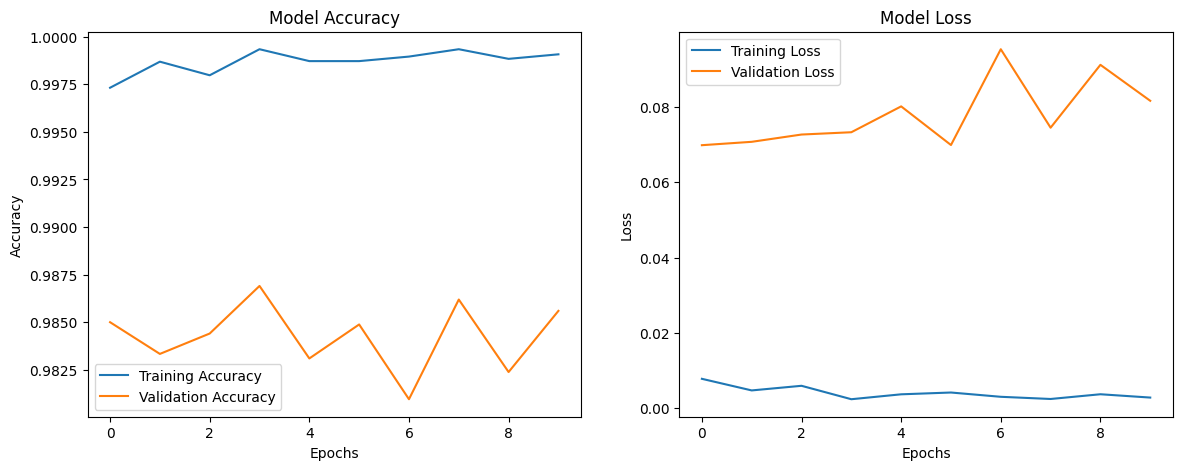

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [37]:
test_loss, test_accuracy = model.evaluate(X_val, y_val)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9856 - loss: 0.0816
Validation Loss: 0.08161458373069763
Validation Accuracy: 0.9855952262878418


In [38]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_val, y_pred))

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       827
           1       0.99      1.00      0.99       937
           2       0.99      0.98      0.99       835
           3       1.00      0.98      0.99       870
           4       0.97      1.00      0.98       814
           5       0.99      0.97      0.98       759
           6       0.99      0.99      0.99       827
           7       0.99      0.99      0.99       880
           8       0.98      0.98      0.98       813
           9       0.98      0.97      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


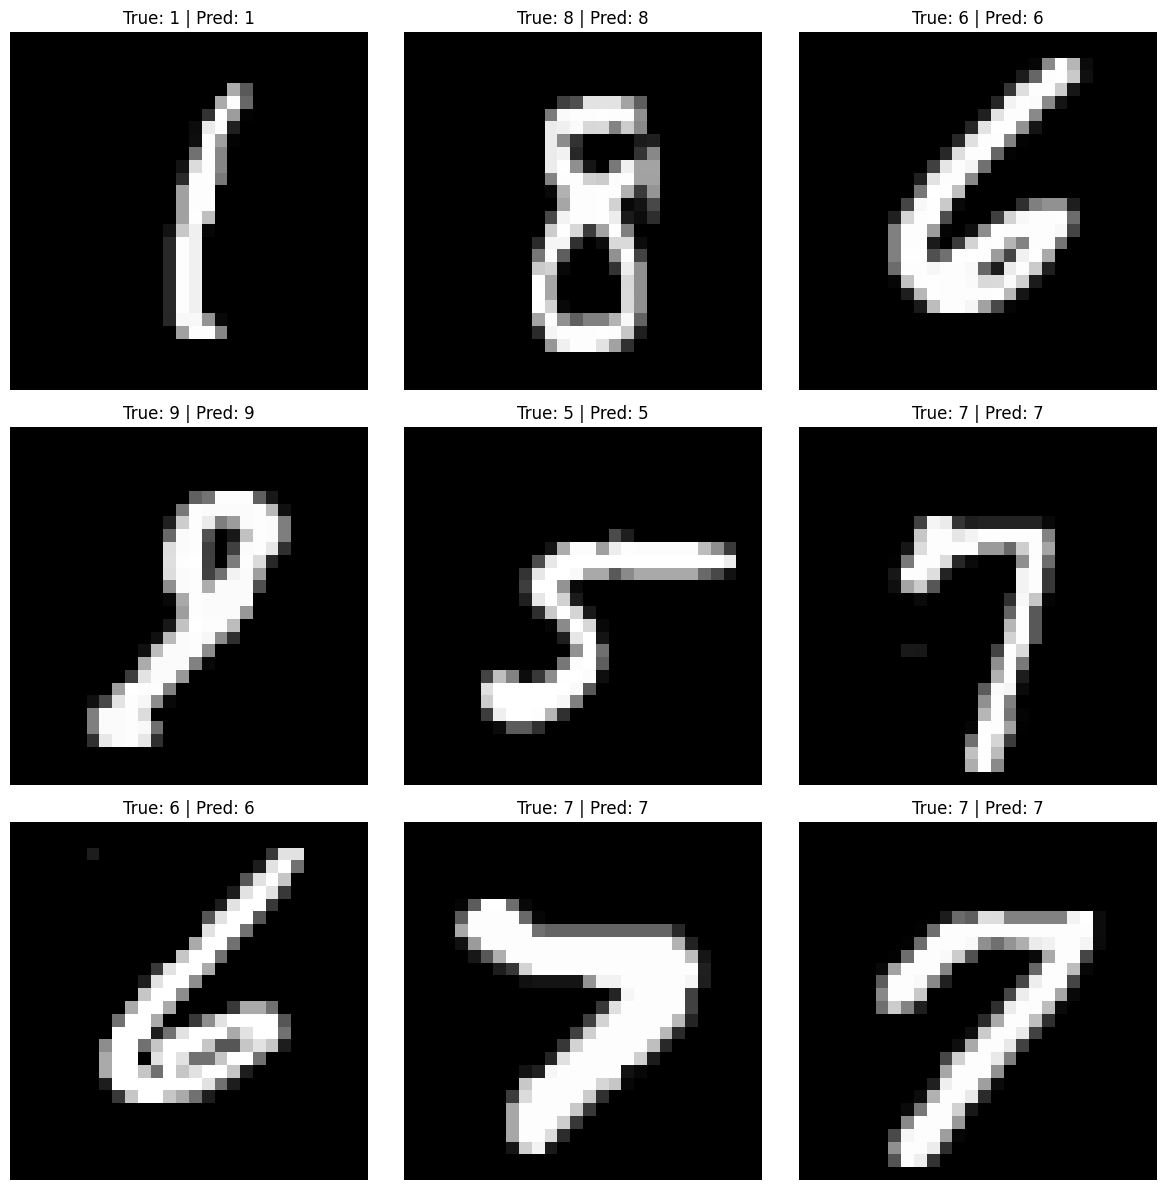

In [39]:
import matplotlib.pyplot as plt
import numpy as np

predictions = model.predict(X_val)
predictions = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_val[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_val[i]} | Pred: {predictions[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


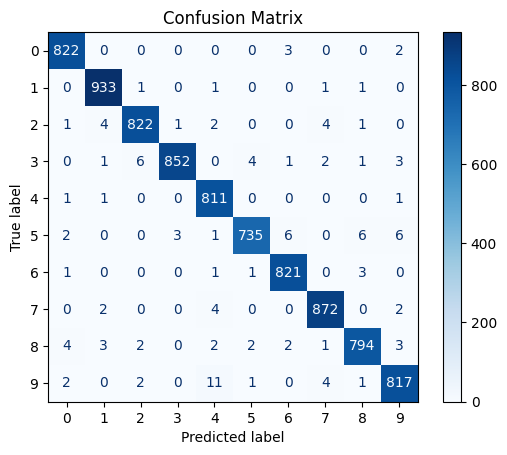

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict on validation data
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [41]:
# Predict targets of validation images
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)

print(y_pred[:10])

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[1 8 6 9 5 7 6 7 7 7]


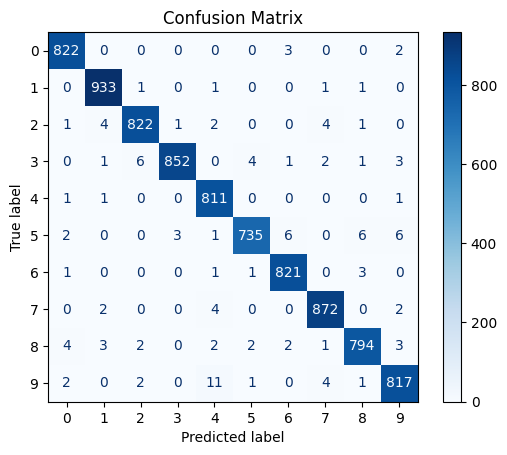

In [42]:
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [43]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       827
           1       0.99      1.00      0.99       937
           2       0.99      0.98      0.99       835
           3       1.00      0.98      0.99       870
           4       0.97      1.00      0.98       814
           5       0.99      0.97      0.98       759
           6       0.99      0.99      0.99       827
           7       0.99      0.99      0.99       880
           8       0.98      0.98      0.98       813
           9       0.98      0.97      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400

